In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

#Read data
pd.set_option('display.max_columns', None)
data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)


#Subset my interested columns
df = data[['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'country_txt', 'region_txt', 'crit1', 'crit2', 'crit3', 'attacktype1_txt', 
           'attacktype2_txt', 'attacktype3_txt', 'targtype1_txt', 'targtype2_txt', 'targtype3_txt', 'gname', 'claimed', 'weaptype1_txt', 'weaptype2_txt',
           'weaptype3_txt', 'nkill', 'nwound', 'extended', 'resolution','INT_LOG', 'INT_IDEO', 'INT_MISC', 'INT_ANY']]

df_post2012 = df[df['iyear'] >= 2012]

#-9 is used frequently throughout the data as an 'unknown' indicator. I'm unsure of the difference between this and missing data. It appears to be
#near interchangable to me. Will have to discuss as a group if we'd like to replace -9 with nan, or leave it as -9 and interpret as unknown

#For right now I'm going to replace with nan
df_post2012 = df_post2012.replace(-9, np.nan)
df_post2012 = df_post2012.replace(-99, np.nan)
df_post2012 = df_post2012.replace("Unknown", np.nan)

#Make a log transformed column for these values to deal with high variance data
df_post2012['log_nkill'] = np.log1p(df_post2012['nkill'])
df_post2012['log_nwound'] = np.log1p(df_post2012['nwound'])

df_post2012['violence_level'] = (
    2 * df_post2012['nkill'].fillna(0) + df_post2012['nwound'].fillna(0)
).where(
    df_post2012['nkill'].notna() | df_post2012['nwound'].notna()
)


print((df_post2012['nkill'] == 0).mean())
print((df_post2012['nwound'] == 0).mean())
print((df_post2012['violence_level'] == 0).mean())

p = 0.997

threshold = df_post2012['violence_level'].quantile(p)

df_trimmed = df_post2012[df_post2012['violence_level'] <= threshold]

#about 44.0% of attacks have no deaths. about 49.6% of all attacks have no wounded, and about 30% of attacks have a violence level of 0 (no kills or wounded)

C:\Users\alist\AppData\Local\Temp\ipykernel_20756\2426504104.py:10: DtypeWarning: Columns (4,31,33,54,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('globalterrorismdb_0221dist.csv', skiprows=[1], skipinitialspace=True)


0.44031453260993597
0.49606315549239083
0.2997811135201303


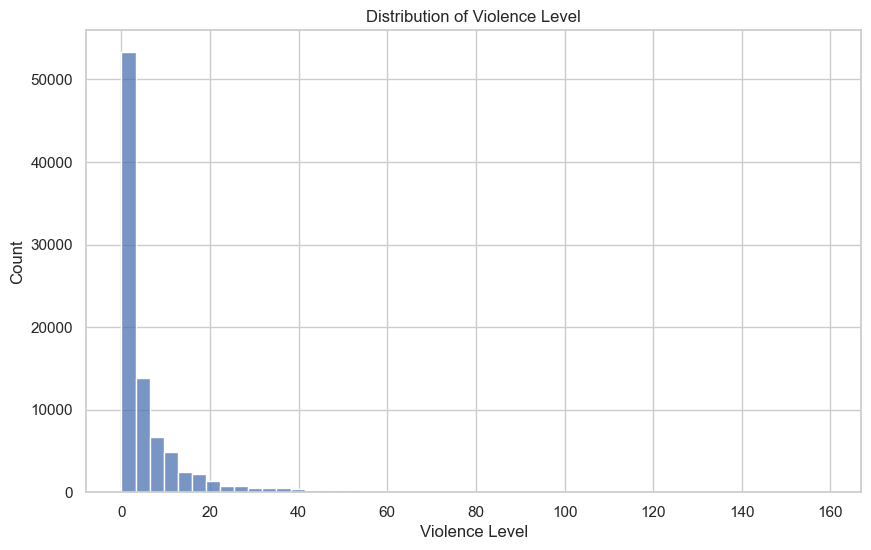

In [6]:
#distribution work:

plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=50)
plt.title('Distribution of Violence Level')
plt.xlabel('Violence Level')
plt.ylabel('Count')
plt.show()

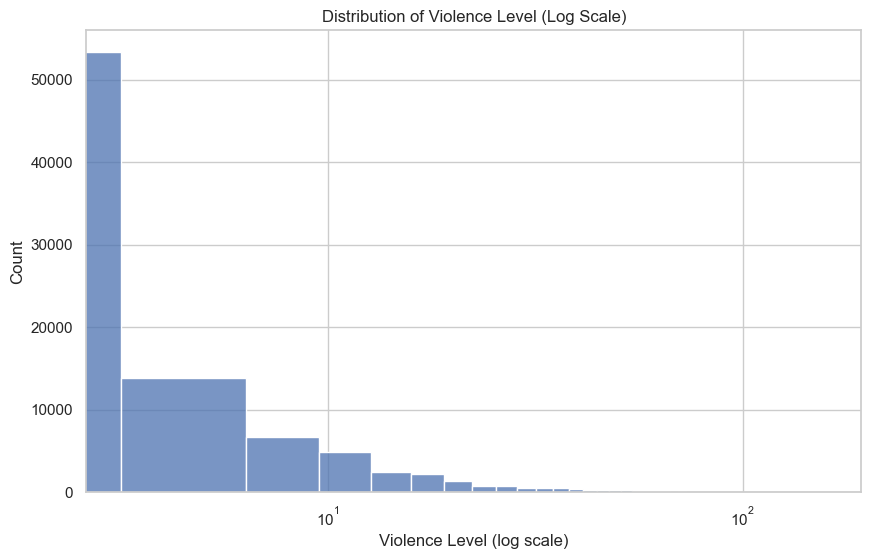

In [8]:
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=50)
plt.xscale('log')
plt.title('Distribution of Violence Level (Log Scale)')
plt.xlabel('Violence Level (log scale)')
plt.ylabel('Count')
plt.show()

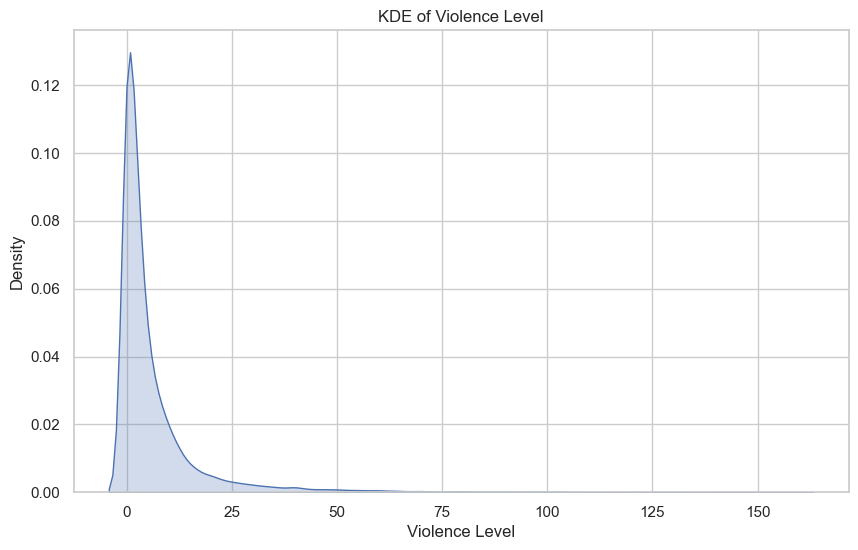

In [10]:
plt.figure(figsize=(10,6))
sns.kdeplot(df_trimmed['violence_level'], fill=True)
plt.title('KDE of Violence Level')
plt.xlabel('Violence Level')
plt.show()

C:\Users\alist\AppData\Local\Temp\ipykernel_20756\2939735994.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trimmed['log_violence'] = np.log1p(df_trimmed['violence_level'])


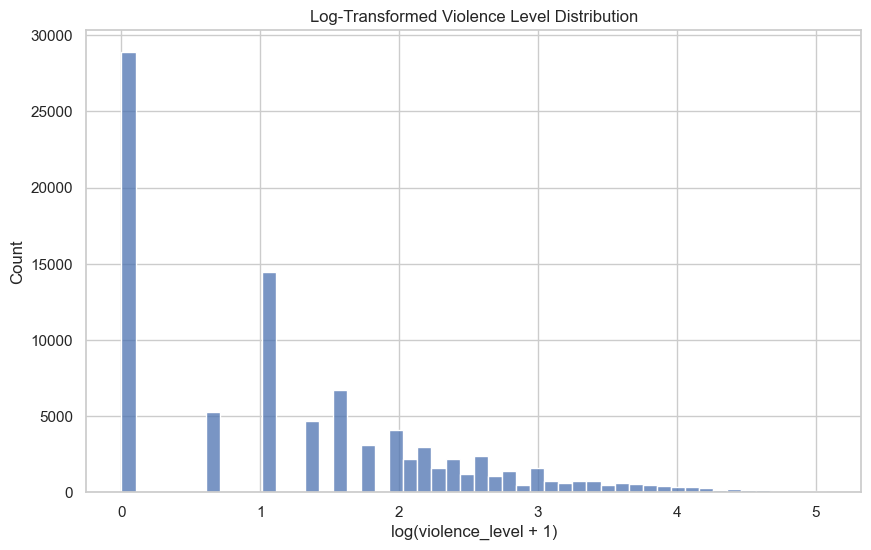

In [12]:
df_trimmed['log_violence'] = np.log1p(df_trimmed['violence_level'])

plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['log_violence'], bins=50)
plt.title('Log-Transformed Violence Level Distribution')
plt.xlabel('log(violence_level + 1)')
plt.ylabel('Count')
plt.show()


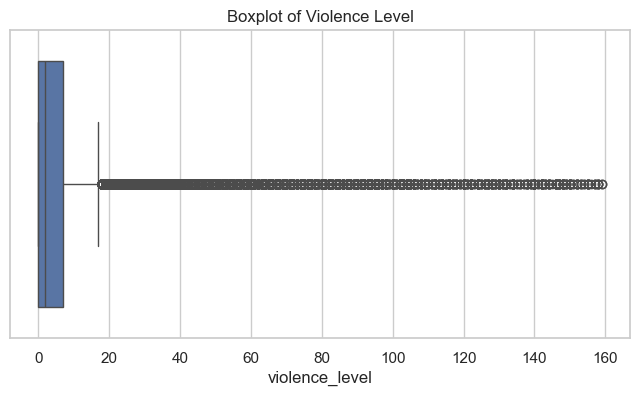

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_trimmed['violence_level'])
plt.title('Boxplot of Violence Level')
plt.show()

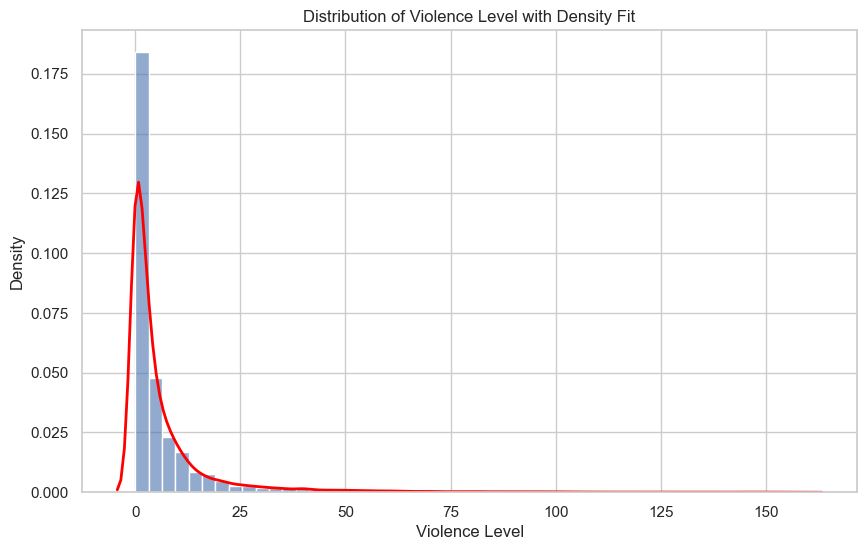

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df_trimmed['violence_level'], bins=50, stat='density', alpha=0.6)
sns.kdeplot(df_trimmed['violence_level'], color='red', linewidth=2)

plt.title('Distribution of Violence Level with Density Fit')
plt.xlabel('Violence Level')
plt.ylabel('Density')
plt.show()

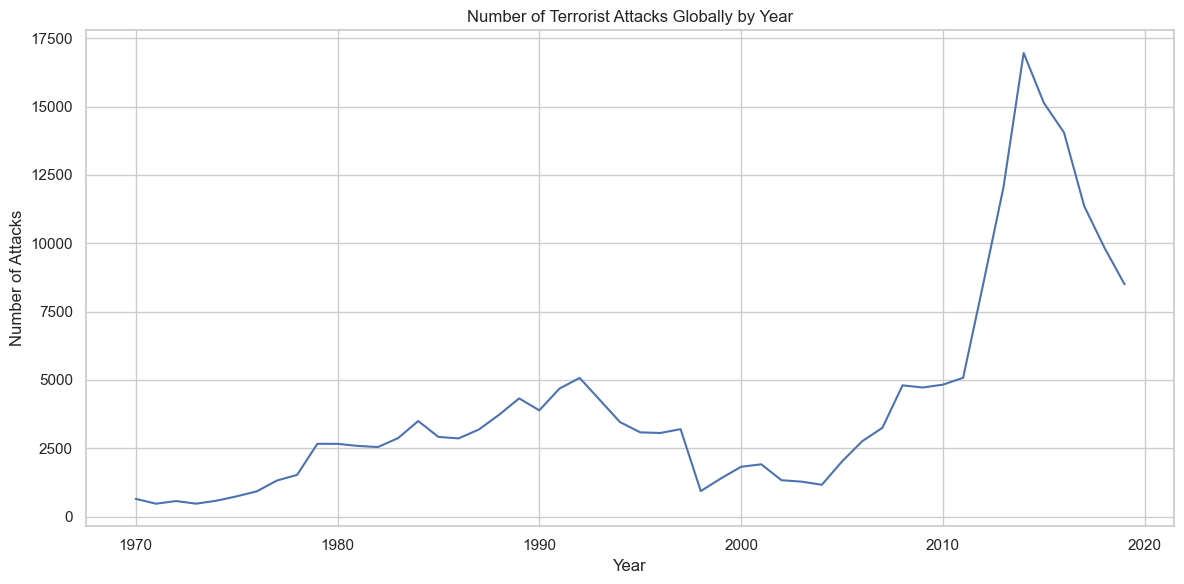

In [56]:
attacks_per_year = (
    df.groupby("iyear")
      .size()
      .reset_index(name="attack_count")
)

plt.figure(figsize=(12, 6))

plt.plot(
    attacks_per_year["iyear"],
    attacks_per_year["attack_count"]
)

plt.title("Number of Terrorist Attacks Globally by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.grid(True)
plt.tight_layout()

plt.show()

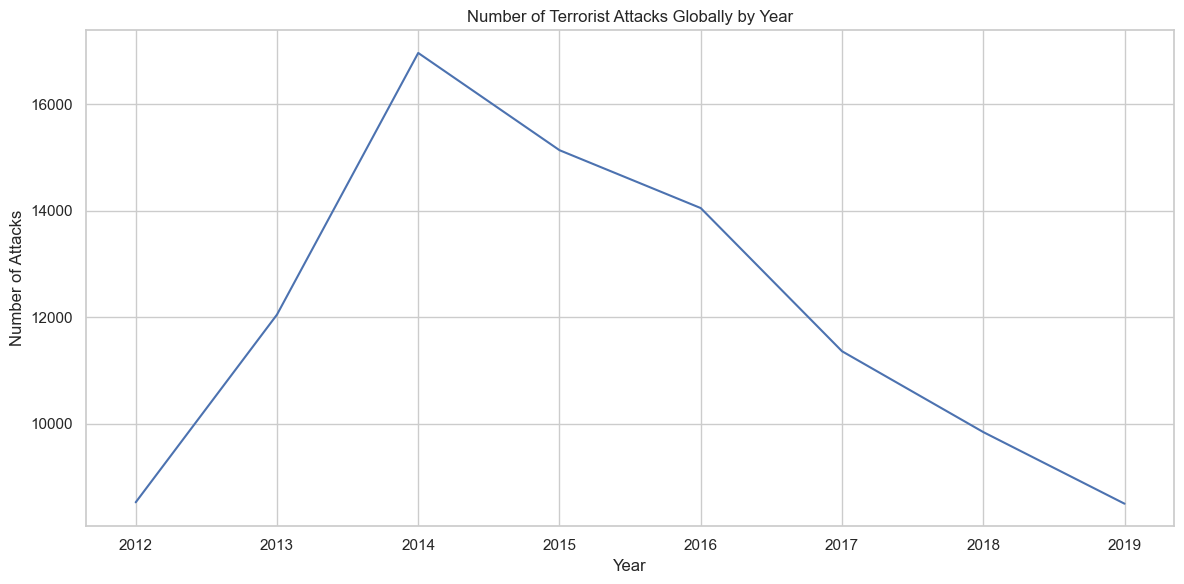

In [57]:
attacks_per_year = (
    df_post2012.groupby("iyear")
      .size()
      .reset_index(name="attack_count")
)

plt.figure(figsize=(12, 6))

plt.plot(
    attacks_per_year["iyear"],
    attacks_per_year["attack_count"]
)

plt.title("Number of Terrorist Attacks Globally by Year")
plt.xlabel("Year")
plt.ylabel("Number of Attacks")

plt.grid(True)
plt.tight_layout()

plt.show()

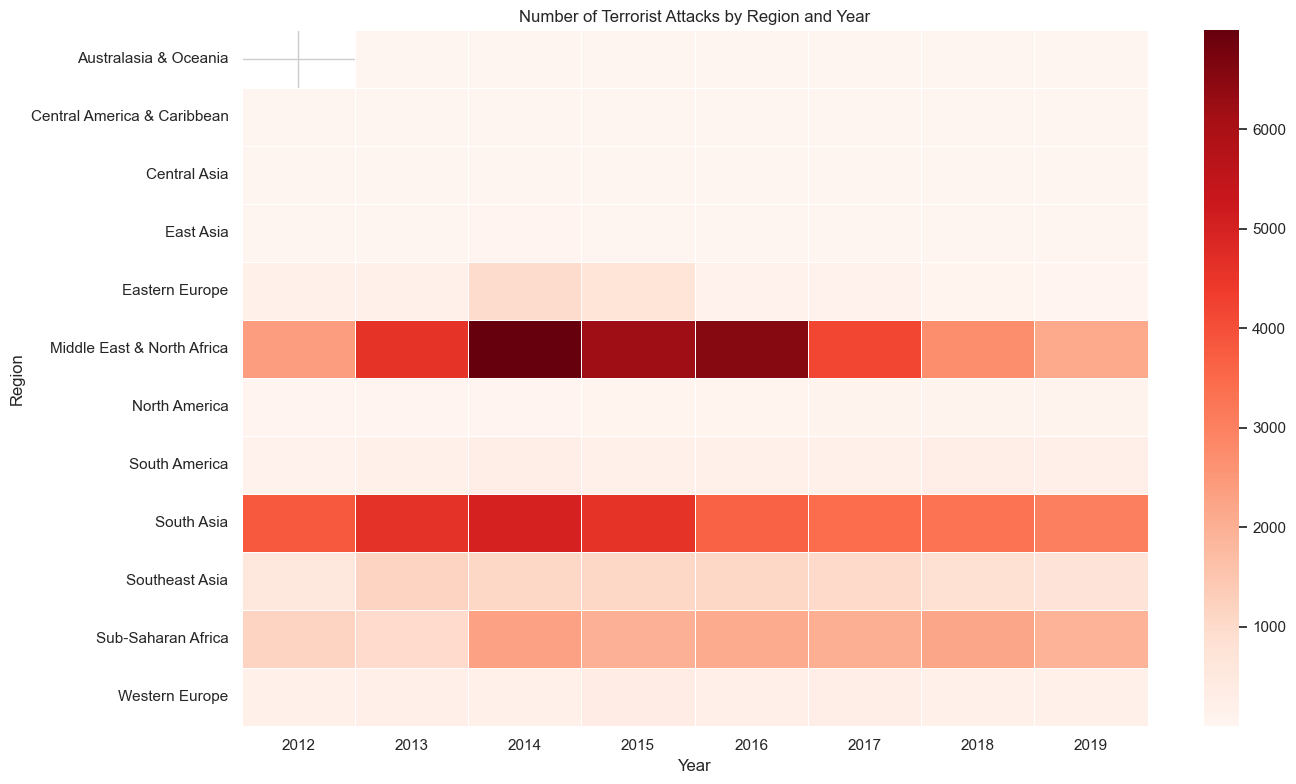

In [58]:
import numpy as np
#Build a heatmap for number of attacks by region
attacks = (df_post2012.groupby(['region_txt', 'iyear']).size().reset_index(name="attack_count"))

heatmap_data = attacks.pivot(
    index="region_txt",
    columns="iyear",
    values="attack_count"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="Reds",
    linewidths=0.5
)

plt.title("Number of Terrorist Attacks by Region and Year")
plt.xlabel("Year")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

<Axes: xlabel='iyear', ylabel='region_txt'>

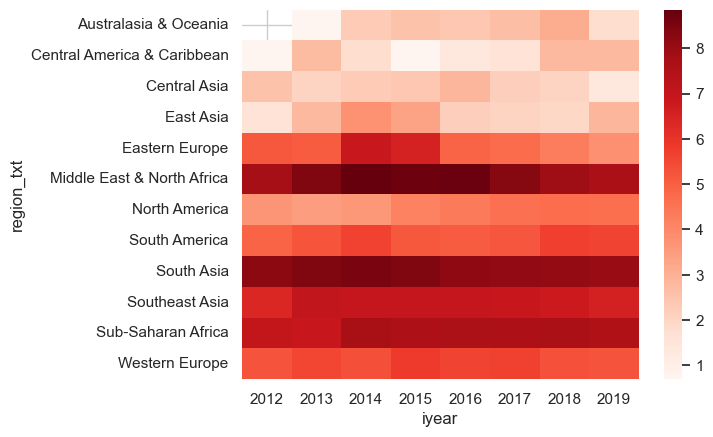

In [63]:
#Because the number of attacks in the middle east and north africa (Specically from 2013-2017)
#cause heavy bias in the graph I tried a log scaled graph so that comparing the other regions/times was easier.
sns.heatmap(
    np.log1p(heatmap_data),
    cmap="Reds"
)

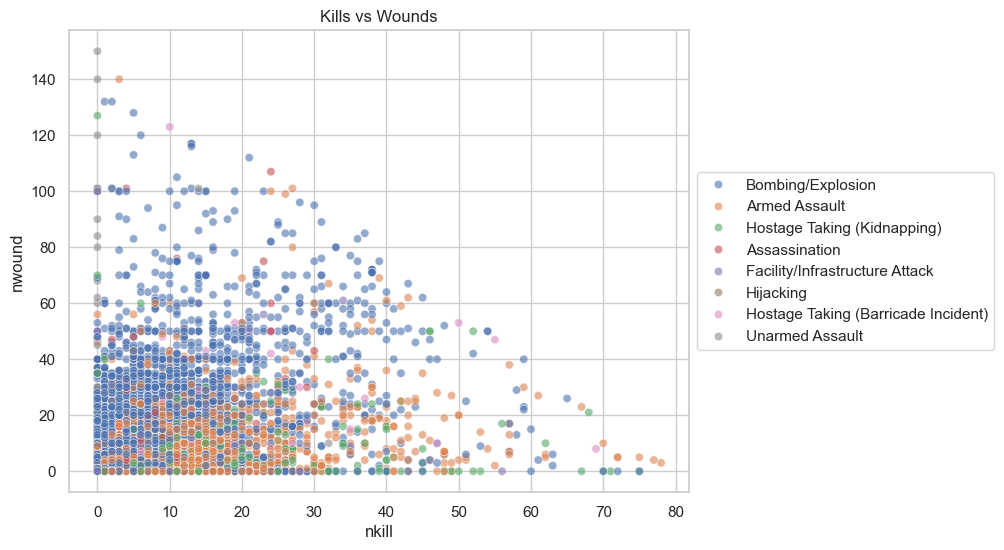

In [65]:
plt.figure(figsize=(8, 6))

#outliers = df_post2012[
#    (df['nkill'] > 400) | 
#    (df['nwound'] > 600)
#]

sns.scatterplot(
    data=df_trimmed,
    x='nkill',
    y='nwound',
    hue='attacktype1_txt',
    alpha=0.6
)
plt.title("Kills vs Wounds")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

#for _, row in outliers.iterrows():
#    label = f"{int(row['iyear'])}-{int(row['imonth'])}-{int(row['iday'])}\n{row['gname']}\n{row['region_txt']}"
    
#    plt.annotate(
#        label,
#        (row['nkill'], row['nwound']),
#        xytext=(5, 5),
#        textcoords='offset points',
#        fontsize=8,
#        alpha=0.8
#    )

plt.show()

#2017-10-1 --- Las Vegas Shooting
#2014-6-10 --- Execution of 600+ prisoners by ISIL (ISIS) (Badush Prison Massacre)
#2016-3-9 --- Chemical weapon attack on Iraqi town of Taza
#2017-10-14 --- Bombing in Somalia


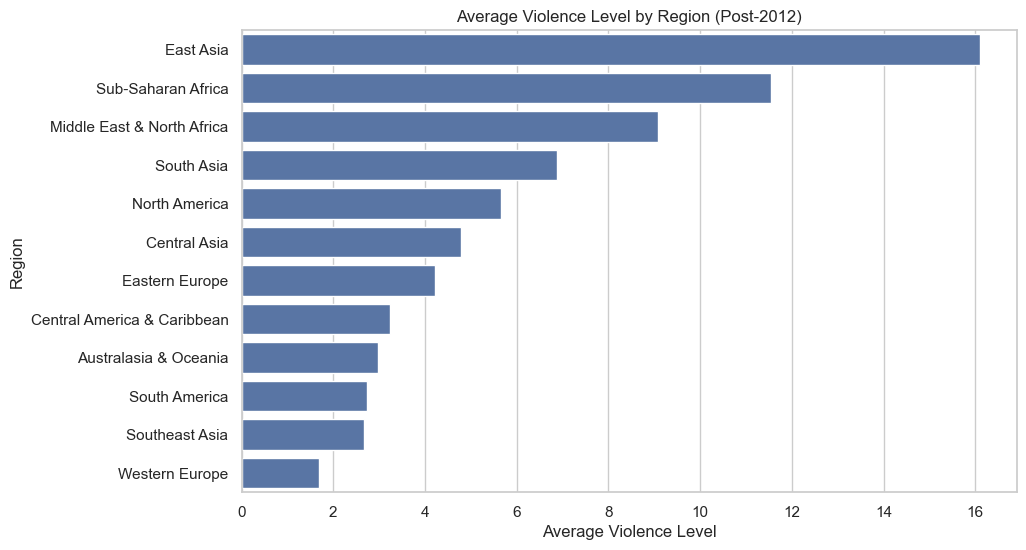

In [52]:
region_avg = (
    df_post2012
    .groupby('region_txt')['violence_level']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.xlabel("Average Violence Level")
plt.ylabel("Region")
plt.title("Average Violence Level by Region (Post-2012)")

plt.show()

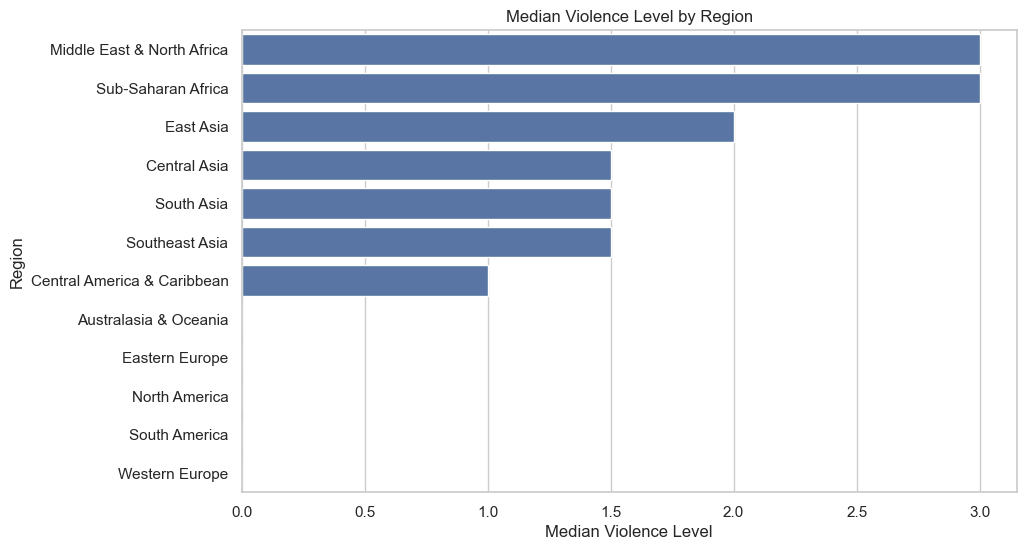

In [70]:
region_avg = (
    df_post2012
    .groupby('region_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=region_avg.values,
    y=region_avg.index
)

plt.xlabel("Median Violence Level")
plt.ylabel("Region")
plt.title("Median Violence Level by Region")

plt.show()

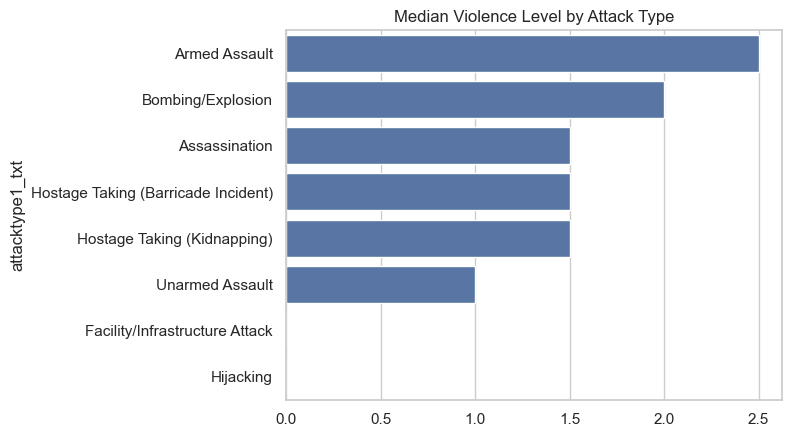

In [72]:
attack_avg = (
    df_post2012
    .groupby('attacktype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_attack_avg = attack_avg.head(10)

sns.barplot(x=top_attack_avg.values, y=top_attack_avg.index)
plt.title("Median Violence Level by Attack Type")
plt.show()


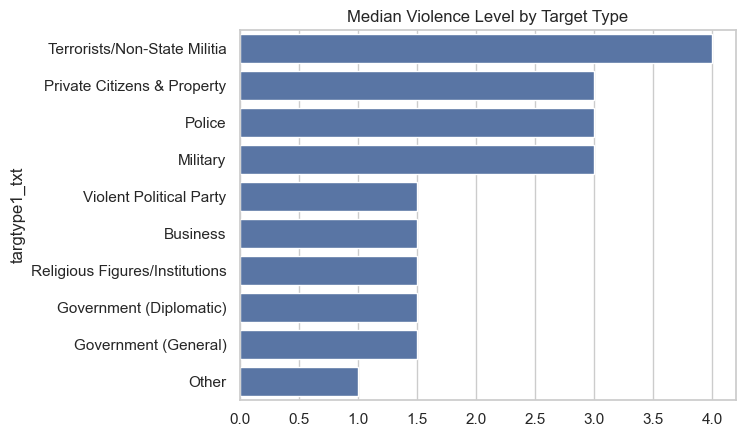

In [74]:
target_avg = (
    df_post2012
    .groupby('targtype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_target_avg = target_avg.head(10)

sns.barplot(x=top_target_avg.values, y=top_target_avg.index)
plt.title("Median Violence Level by Target Type")
plt.show()

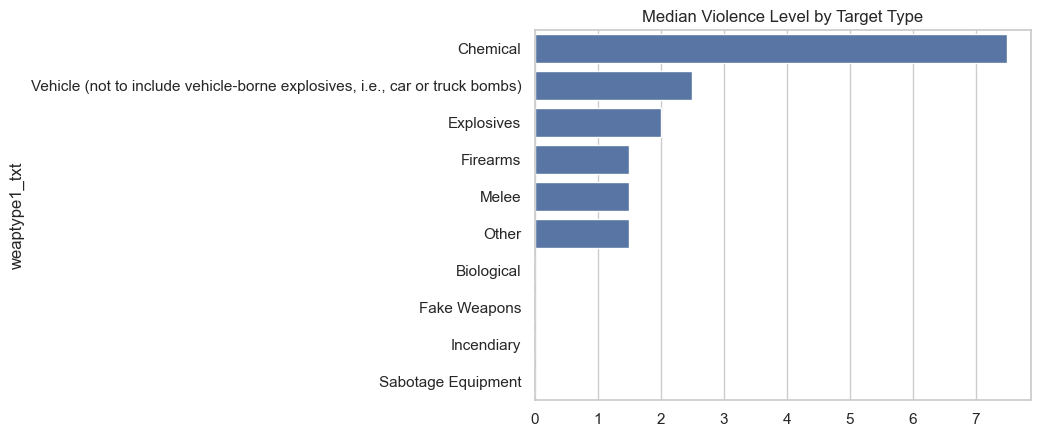

In [76]:
weapon_avg = (
    df_post2012
    .groupby('weaptype1_txt')['violence_level']
    .median()
    .sort_values(ascending=False)
)

top_weapon_avg = weapon_avg.head(10)

sns.barplot(x=top_weapon_avg.values, y=top_weapon_avg.index)
plt.title("Median Violence Level by Weapon Type")
plt.show()

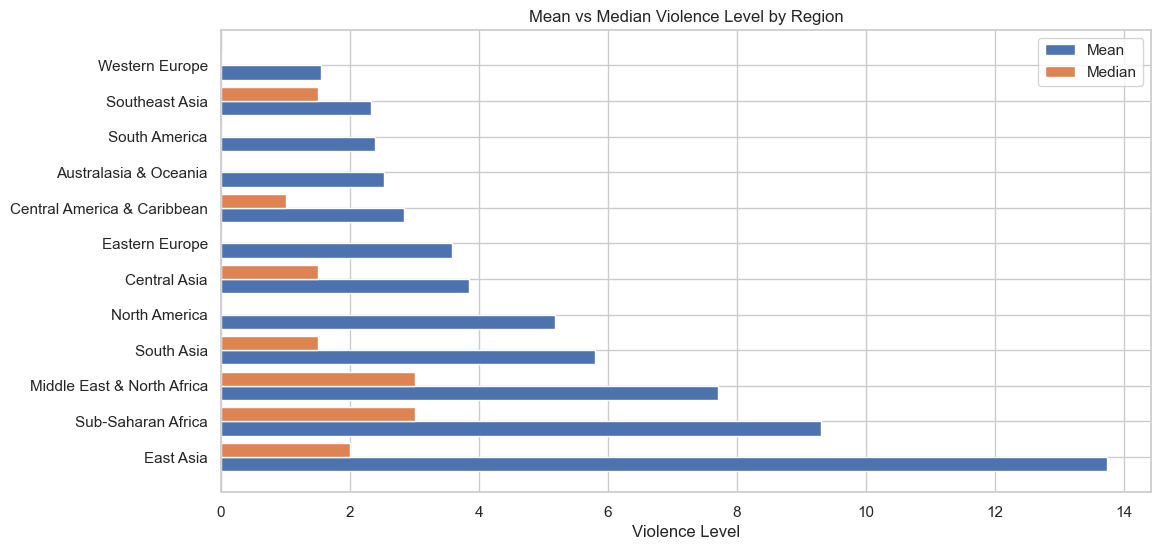

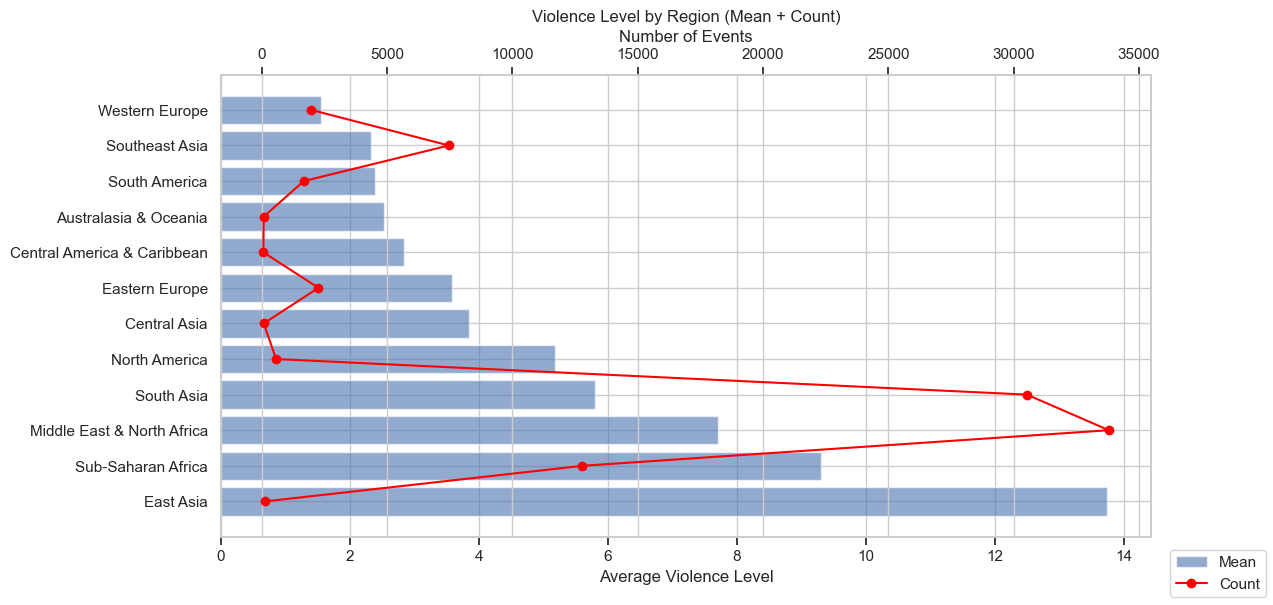

In [81]:
region_stats = (
    df_post2012
    .groupby('region_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

region_stats = region_stats[region_stats['count'] > 50]

region_stats = region_stats.sort_values('mean', ascending=False)

x = np.arange(len(region_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, region_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, region_stats['median'], height=width, label='Median')

plt.yticks(x, region_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Region")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(region_stats.index, region_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(region_stats['count'], region_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Region (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

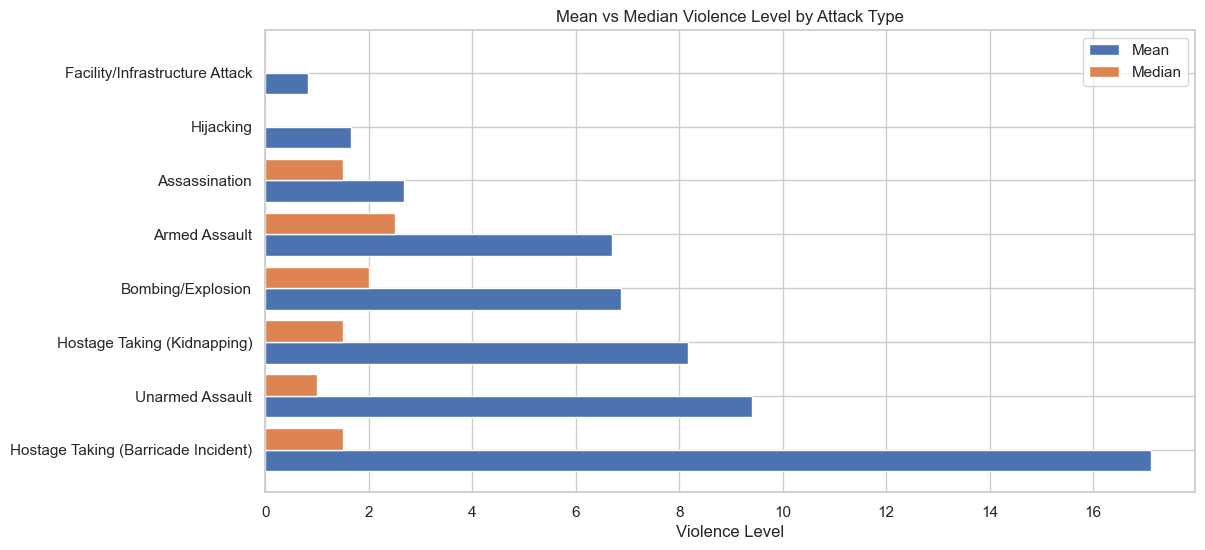

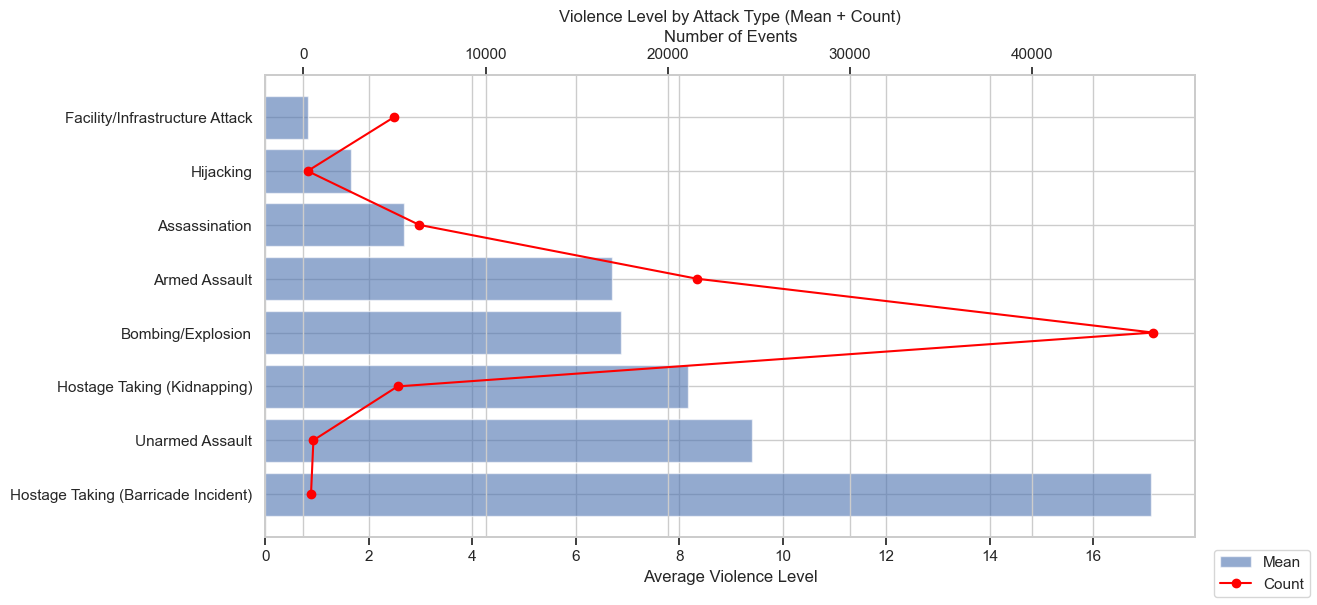

In [85]:
attack_stats = (
    df_post2012
    .groupby('attacktype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

attack_stats = attack_stats[attack_stats['count'] > 50]

attack_stats = attack_stats.sort_values('mean', ascending=False)

x = np.arange(len(attack_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, attack_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, attack_stats['median'], height=width, label='Median')

plt.yticks(x, attack_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Attack Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(attack_stats.index, attack_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(attack_stats['count'], attack_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Attack Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

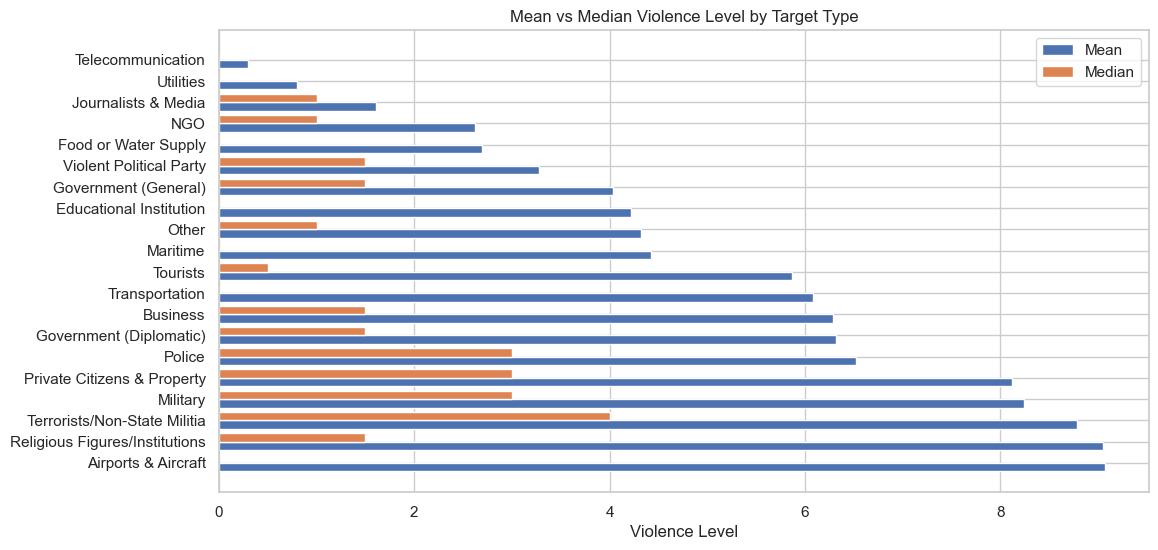

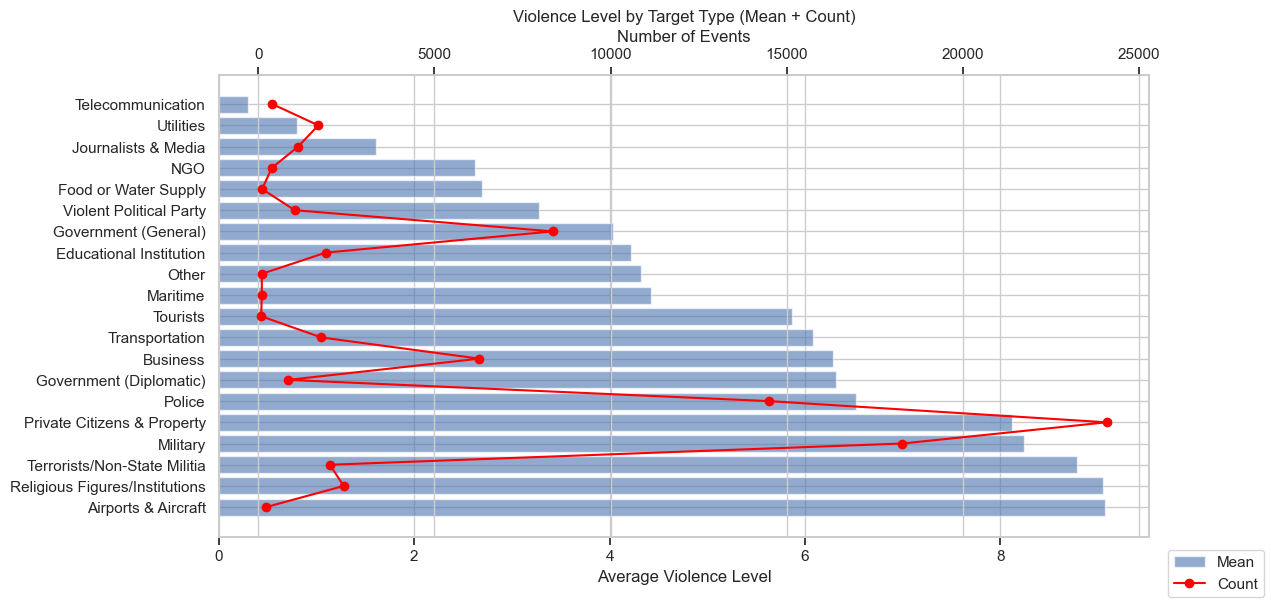

In [87]:
target_stats = (
    df_post2012
    .groupby('targtype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

target_stats = target_stats[target_stats['count'] > 50]

target_stats = target_stats.sort_values('mean', ascending=False)

x = np.arange(len(target_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, target_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, target_stats['median'], height=width, label='Median')

plt.yticks(x, target_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Target Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(target_stats.index, target_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(target_stats['count'], target_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Target Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

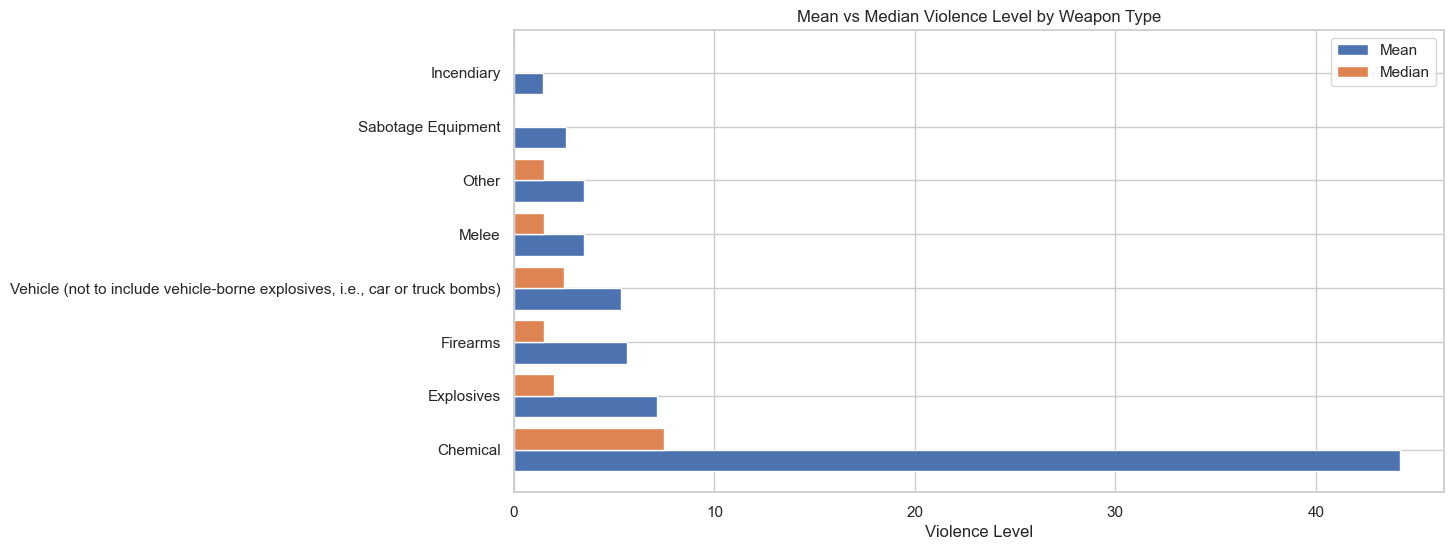

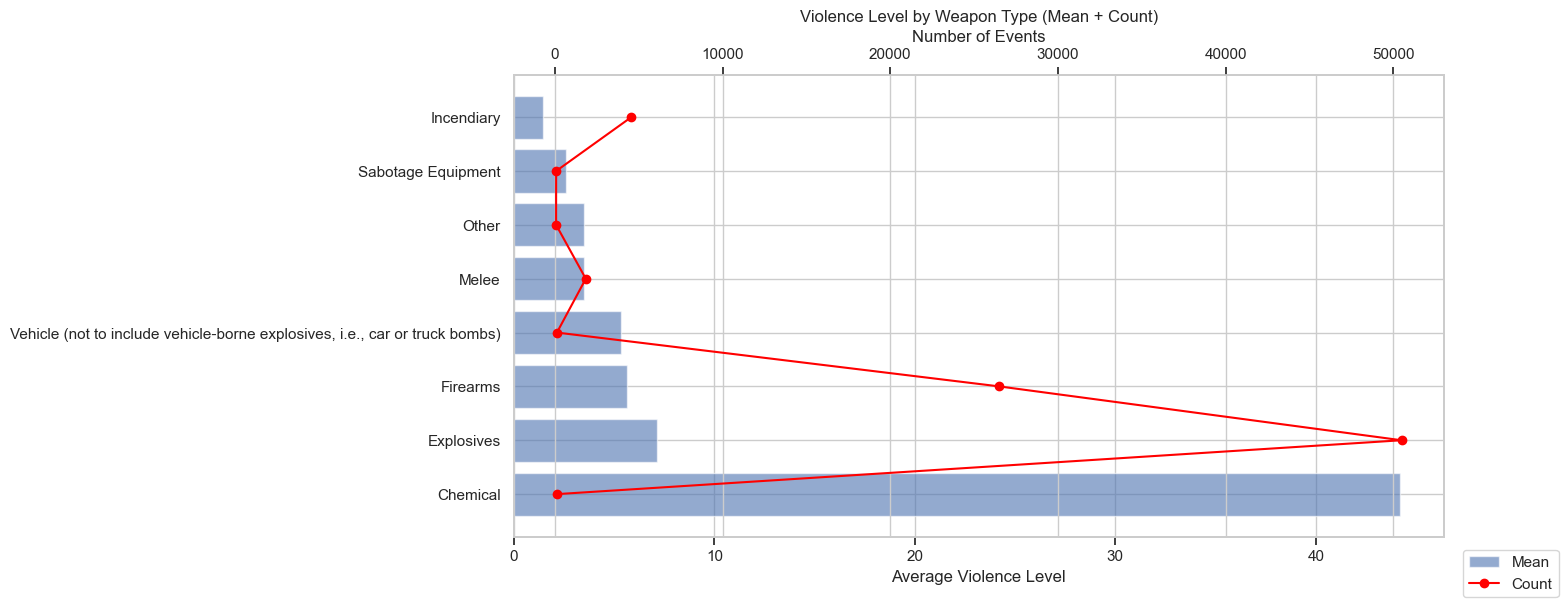

In [91]:
weapon_stats = (
    df_post2012
    .groupby('weaptype1_txt')['violence_level']
    .agg(['mean', 'median', 'count'])
)

weapon_stats = weapon_stats[weapon_stats['count'] > 50]

weapon_stats = weapon_stats.sort_values('mean', ascending=False)

x = np.arange(len(weapon_stats))
width = 0.4

plt.figure(figsize=(12, 6))

plt.barh(x - width/2, weapon_stats['mean'], height=width, label='Mean')
plt.barh(x + width/2, weapon_stats['median'], height=width, label='Median')

plt.yticks(x, weapon_stats.index)
plt.xlabel("Violence Level")
plt.title("Mean vs Median Violence Level by Weapon Type")

plt.legend()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Mean bars
ax1.barh(weapon_stats.index, weapon_stats['mean'], alpha=0.6, label='Mean')
ax1.set_xlabel("Average Violence Level")

# Second axis for counts
ax2 = ax1.twiny()
ax2.plot(weapon_stats['count'], weapon_stats.index, 'o-', color='red', label='Count')
ax2.set_xlabel("Number of Events")

plt.title("Violence Level by Weapon Type (Mean + Count)")

fig.legend(loc='lower right')
plt.show()

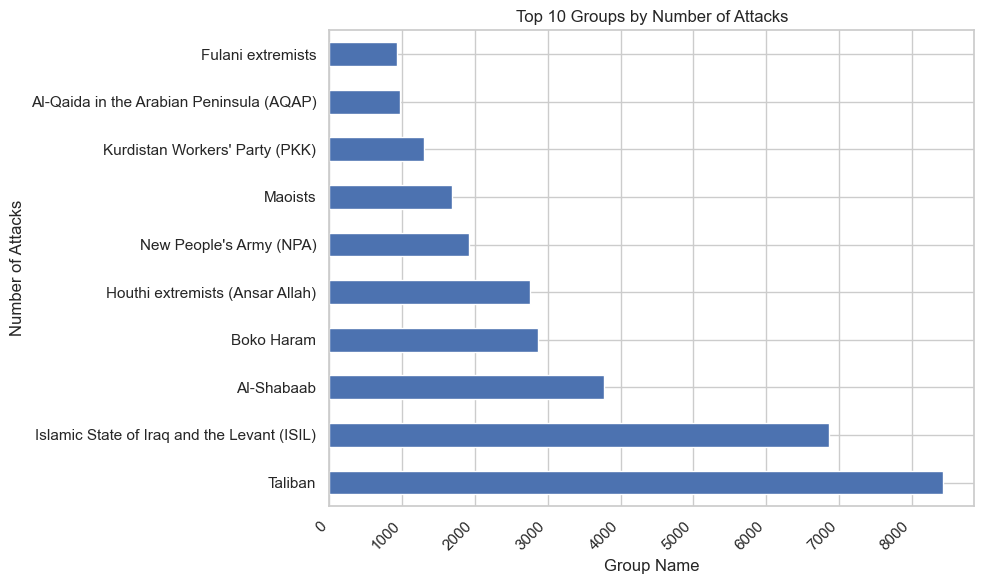

In [69]:
top10_counts = df_post2012['gname'].value_counts().head(10)
top10_groups = df_post2012['gname'].value_counts().head(10).index
df_top10 = df_post2012[df_post2012['gname'].isin(top10_groups)]

plt.figure(figsize=(10,6))

top10_counts.plot(kind='barh')

plt.ylabel("Number of Attacks")
plt.xlabel("Group Name")
plt.title("Top 10 Groups by Number of Attacks")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

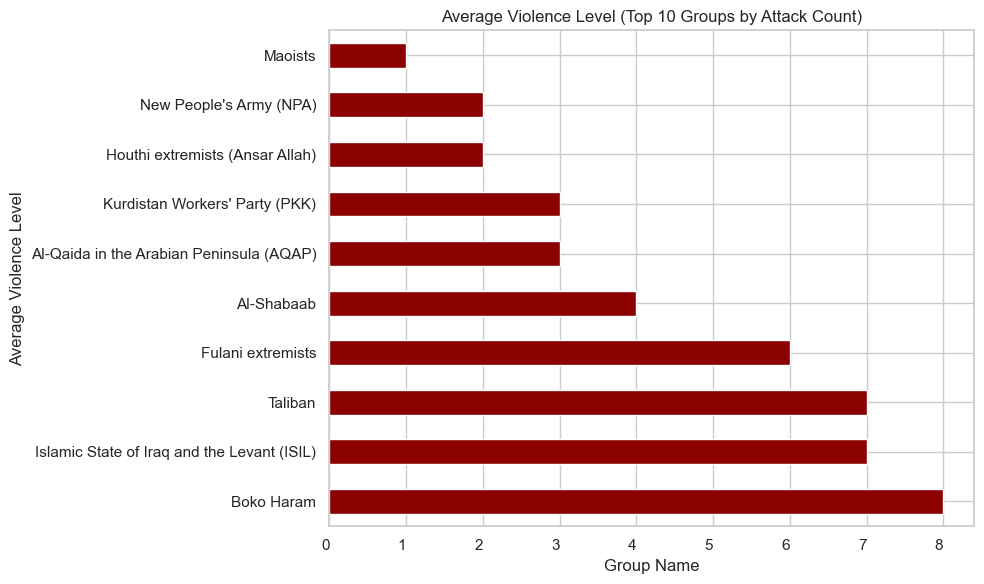

In [71]:
top10_violence = (
    df_top10
    .groupby('gname')['violence_level']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

top10_violence.plot(kind='barh', color='darkred')

plt.ylabel("Average Violence Level")
plt.xlabel("Group Name")
plt.title("Average Violence Level (Top 10 Groups by Attack Count)")

plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

In [95]:
pd.crosstab(
    df_post2012['region_txt'],
    df_post2012['attacktype1_txt'],
    normalize='index'
)

weaptype1_txt,Biological,Chemical,Explosives,Fake Weapons,Firearms,Incendiary,Melee,Other,Sabotage Equipment,"Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)"
region_txt,,,,,,,,,,
Australasia & Oceania,0.000000,0.000000,0.028571,0.000000,0.100000,0.785714,0.071429,0.000000,0.000000,0.014286
Central America & Caribbean,0.000000,0.000000,0.214286,0.000000,0.660714,0.125000,0.000000,0.000000,0.000000,0.000000
Central Asia,0.000000,0.000000,0.385714,0.000000,0.342857,0.142857,0.128571,0.000000,0.000000,0.000000
East Asia,0.000000,0.015748,0.409449,0.000000,0.007874,0.259843,0.291339,0.000000,0.000000,0.015748
Eastern Europe,0.000000,0.002751,0.682714,0.000459,0.231087,0.053645,0.027052,0.000459,0.001834,0.000000
Middle East & North Africa,0.000031,0.001861,0.745176,0.000000,0.212043,0.019824,0.017497,0.000558,0.000589,0.002420
North America,0.005329,0.015986,0.159858,0.000000,0.353464,0.323268,0.110124,0.003552,0.003552,0.024867
South America,0.000000,0.001979,0.546834,0.000660,0.328496,0.105541,0.009894,0.000660,0.005937,0.000000
South Asia,0.000000,0.002148,0.586397,0.000036,0.337068,0.053517,0.018901,0.000644,0.001038,0.000251


In [117]:
pd.crosstab(
    df_post2012['region_txt'],
    df_post2012['targtype1_txt'],
    normalize='index'
)

targtype1_txt,Abortion Related,Airports & Aircraft,Business,Educational Institution,Food or Water Supply,Government (Diplomatic),Government (General),Journalists & Media,Maritime,Military,NGO,Other,Police,Private Citizens & Property,Religious Figures/Institutions,Telecommunication,Terrorists/Non-State Militia,Tourists,Transportation,Utilities,Violent Political Party
region_txt,,,,,,,,,,,,,,,,,,,,,
Australasia & Oceania,0.000,0.014085,0.366197,0.042254,0.000000,0.000000,0.070423,0.014085,0.000000,0.000000,0.000000,0.000000,0.084507,0.098592,0.309859,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Central America & Caribbean,0.000,0.000000,0.035714,0.000000,0.000000,0.000000,0.267857,0.321429,0.000000,0.000000,0.000000,0.000000,0.142857,0.125000,0.035714,0.000000,0.000000,0.000000,0.035714,0.000000,0.035714
Central Asia,0.000,0.000000,0.086957,0.014493,0.000000,0.072464,0.246377,0.043478,0.000000,0.086957,0.014493,0.000000,0.173913,0.202899,0.057971,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
East Asia,0.000,0.023622,0.118110,0.015748,0.000000,0.031496,0.102362,0.015748,0.000000,0.039370,0.000000,0.000000,0.259843,0.244094,0.015748,0.000000,0.000000,0.000000,0.133858,0.000000,0.000000
Eastern Europe,0.000,0.001748,0.059878,0.009615,0.003497,0.014860,0.076486,0.037150,0.000000,0.393357,0.007867,0.001748,0.118007,0.178759,0.031906,0.001311,0.004808,0.001748,0.038899,0.017045,0.001311
Middle East & North Africa,0.000,0.003131,0.071933,0.013898,0.001282,0.006382,0.063285,0.013092,0.001133,0.236319,0.003340,0.001700,0.135039,0.343712,0.022994,0.000775,0.041752,0.000984,0.013152,0.018729,0.007366
North America,0.025,0.010714,0.096429,0.026786,0.001786,0.005357,0.092857,0.132143,0.000000,0.021429,0.007143,0.001786,0.062500,0.235714,0.232143,0.003571,0.000000,0.001786,0.028571,0.012500,0.001786
South America,0.000,0.004297,0.124616,0.007366,0.003069,0.004911,0.062615,0.030694,0.000614,0.173726,0.001842,0.000614,0.189073,0.169429,0.020872,0.004911,0.004297,0.003069,0.051565,0.142419,0.000000
South Asia,0.000,0.001624,0.065054,0.034859,0.000864,0.004491,0.109069,0.009708,0.000311,0.177820,0.004457,0.000484,0.253964,0.215063,0.024460,0.008257,0.020107,0.000415,0.027639,0.015754,0.025600


In [119]:
pd.crosstab(
    df_post2012['region_txt'],
    df_post2012['weaptype1_txt'],
    normalize='index'
)

weaptype1_txt,Biological,Chemical,Explosives,Fake Weapons,Firearms,Incendiary,Melee,Other,Sabotage Equipment,"Vehicle (not to include vehicle-borne explosives, i.e., car or truck bombs)"
region_txt,,,,,,,,,,
Australasia & Oceania,0.000000,0.000000,0.028571,0.000000,0.100000,0.785714,0.071429,0.000000,0.000000,0.014286
Central America & Caribbean,0.000000,0.000000,0.214286,0.000000,0.660714,0.125000,0.000000,0.000000,0.000000,0.000000
Central Asia,0.000000,0.000000,0.385714,0.000000,0.342857,0.142857,0.128571,0.000000,0.000000,0.000000
East Asia,0.000000,0.015748,0.409449,0.000000,0.007874,0.259843,0.291339,0.000000,0.000000,0.015748
Eastern Europe,0.000000,0.002751,0.682714,0.000459,0.231087,0.053645,0.027052,0.000459,0.001834,0.000000
Middle East & North Africa,0.000031,0.001861,0.745176,0.000000,0.212043,0.019824,0.017497,0.000558,0.000589,0.002420
North America,0.005329,0.015986,0.159858,0.000000,0.353464,0.323268,0.110124,0.003552,0.003552,0.024867
South America,0.000000,0.001979,0.546834,0.000660,0.328496,0.105541,0.009894,0.000660,0.005937,0.000000
South Asia,0.000000,0.002148,0.586397,0.000036,0.337068,0.053517,0.018901,0.000644,0.001038,0.000251
